# Benchmark: Chenran's Loop-Based CIC vs. Current Optimized CIC
This notebook benchmarks the performance of the current optimized Cloud-in-Cell (CIC) charge deposition implementation against the original loop-based implementation right after Chenran Xu's fixes (commit `c3cd873a`).

Chenran's implementation is loop-based and constructs corner weights and indices dynamically, scaling the final charge density by the inverse cell volume. The current implementation is fully tensorised with unrolled specialized paths for 1D, 2D, and 3D coordinate processing and contiguous coordinate unpacking.

In [1]:
import sys
import os
import time
import math
from typing import Sequence
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import platform
import subprocess
import re
import glob

repo_root = os.path.abspath(".")
if repo_root not in sys.path:
    sys.path.append(repo_root)

import cheetah.utils.cloud_in_cell as cic_tensor

device_types = ["cpu"]
if torch.cuda.is_available():
    device_types.append("cuda")
if torch.backends.mps.is_available():
    device_types.append("mps")
print(f"Available devices: {device_types}")

def sync(device):
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()

Available devices: ['cpu', 'mps']


In [2]:
def get_cpu_info():
    try:
        if platform.system() == "Windows":
            return platform.processor()
        elif platform.system() == "Darwin":
            return subprocess.check_output(["sysctl", "-n", "machdep.cpu.brand_string"]).decode().strip()
        elif platform.system() == "Linux":
            with open("/proc/cpuinfo", "r") as f:
                for line in f:
                    if "model name" in line:
                        return re.sub(".*model name.*:", "", line, 1).strip()
    except Exception:
        pass
    return platform.processor() or "Unknown CPU"

def get_ram_info():
    try:
        import psutil
        return f"{psutil.virtual_memory().total / (1024**3):.1f} GB"
    except ImportError:
        pass
    try:
        if platform.system() == "Darwin":
            mem_bytes = int(subprocess.check_output(["sysctl", "-n", "hw.memsize"]).decode().strip())
            return f"{mem_bytes / (1024**3):.1f} GB"
        elif platform.system() == "Linux":
            with open("/proc/meminfo", "r") as f:
                for line in f:
                    if "MemTotal" in line:
                        mem_kb = int(line.split()[1])
                        return f"{mem_kb / (1024**2):.1f} GB"
    except Exception:
        pass
    return "Unknown RAM"

def get_gpu_info():
    gpus = []
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            gpus.append(torch.cuda.get_device_name(i))
    if torch.backends.mps.is_available():
        gpus.append("Apple Silicon Integrated GPU (MPS)")
    return ", ".join(gpus) if gpus else "None"

cpu_info = get_cpu_info()
ram_info = get_ram_info()
gpu_info = get_gpu_info()
os_info = f"{platform.system()} {platform.release()}"

system_label = f"{os_info} | {cpu_info} | RAM: {ram_info}"
if gpu_info != "None":
    system_label += f" | GPU: {gpu_info}"

print("System Information:")
print(f"OS:  {os_info}")
print(f"CPU: {cpu_info}")
print(f"RAM: {ram_info}")
print(f"GPU: {gpu_info}")
print(f"Label: {system_label}")

System Information:
OS:  Darwin 25.5.0
CPU: Apple M1 Pro
RAM: 32.0 GB
GPU: Apple Silicon Integrated GPU (MPS)
Label: Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | GPU: Apple Silicon Integrated GPU (MPS)


In [3]:
def deposit_charge_cic_chenran(
    positions: Sequence[torch.Tensor],
    bins: Sequence[torch.Tensor],
    weights: torch.Tensor | None = None,
) -> torch.Tensor:
    # Validate inputs
    if not positions:
        raise ValueError("positions list cannot be empty")
    if len(positions) != len(bins):
        raise ValueError("Number of position tensors must match number of bin arrays")
    
    ndim = len(positions)
    first_pos = positions[0]
    device = first_pos.device
    dtype = first_pos.dtype

    # Validate all position tensors have the same shape
    for i, pos in enumerate(positions[1:], 1):
        if pos.shape != first_pos.shape:
            raise ValueError(
                f"All position tensors must have the same shape. "
                f"positions[0] has shape {first_pos.shape}, "
                f"positions[{i}] has shape {pos.shape}"
            )
        if pos.device != device:
            raise ValueError("All tensors must be on the same device")
        if pos.dtype != dtype:
            raise ValueError("All tensors must have the same dtype")

    # Grid dimensions and spacing validation
    grid_sizes = []
    spacings = []

    for i, bin_array in enumerate(bins):
        N = bin_array.numel()
        if N < 2:
            raise ValueError(f"bins[{i}] must have at least 2 elements")
        spacing = bin_array[1] - bin_array[0]
        if N > 2:
            diffs = torch.diff(bin_array)
            if not torch.allclose(diffs, spacing, rtol=1e-4):
                raise ValueError(f"bins[{i}] must have uniform spacing")
        grid_sizes.append(N)
        spacings.append(spacing)

    if weights is None:
        weights = torch.ones_like(first_pos)

    # Set weights to zero for particles outside grid bounds
    for pos, bin_array in zip(positions, bins):
        outside_mask = (pos < bin_array[0]) | (pos >= bin_array[-1])
        weights = weights * (~outside_mask).float()

    # Normalize particle coordinates to grid index space
    grid_indices = []
    fractional_parts = []

    for pos, bin_array, spacing in zip(positions, bins, spacings):
        # Normalized coordinate in grid index space
        u = (pos - bin_array[0]) / spacing
        # Left cell index
        i = torch.floor(u).to(torch.int64)
        grid_indices.append(i)
        # Fractional distance to right cell
        w = u - i
        fractional_parts.append(w)

    # Generate all corner combinations and their weights
    num_corners = 2**ndim
    corner_indices = []
    corner_weights = []

    for corner in range(num_corners):
        corner_offsets = []
        weight_factors = []
        for dim in range(ndim):
            if (corner >> dim) & 1:  # Use right cell in this dimension
                corner_offsets.append(1)
                weight_factors.append(fractional_parts[dim])
            else:  # Use left cell in this dimension
                corner_offsets.append(0)
                weight_factors.append(1 - fractional_parts[dim])

        corner_idx_list = []
        for dim in range(ndim):
            base_idx = grid_indices[dim]
            offset_idx = (base_idx + corner_offsets[dim]).clamp(0, grid_sizes[dim] - 1)
            corner_idx_list.append(offset_idx)

        corner_weight = weights
        for weight_factor in weight_factors:
            corner_weight = corner_weight * weight_factor
        corner_indices.append(corner_idx_list)
        corner_weights.append(corner_weight)

    def multi_to_flat_index(idx_list):
        flat_idx = idx_list[0]
        stride = 1
        for dim in range(1, ndim):
            stride *= grid_sizes[dim - 1]
            flat_idx = flat_idx + idx_list[dim] * stride
        return flat_idx

    batch_shape = first_pos.shape[:-1]
    B = int(torch.tensor(batch_shape).prod()) if batch_shape else 1
    N = first_pos.shape[-1]

    def flatten_tensor(t):
        return t.reshape(B, N)

    all_flat_indices = []
    all_weights = []
    for corner_idx_list, corner_weight in zip(corner_indices, corner_weights):
        flat_idx = multi_to_flat_index(corner_idx_list)
        all_flat_indices.append(flatten_tensor(flat_idx))
        all_weights.append(flatten_tensor(corner_weight))

    idx_all = torch.cat(all_flat_indices, dim=1)
    vals_all = torch.cat(all_weights, dim=1)

    total_grid_size = int(torch.tensor(grid_sizes).prod())
    charge = torch.zeros((B, total_grid_size), dtype=dtype, device=device)
    for b in range(B):
        charge[b].index_add_(0, idx_all[b], vals_all[b])

    cell_volume = 1.0
    for spacing in spacings:
        cell_volume *= spacing
    inv_cell_volume = 1.0 / cell_volume
    charge = charge * inv_cell_volume

    out_shape = (*batch_shape, *grid_sizes[::-1])
    charge = charge.reshape(out_shape)
    batch_ndim = len(batch_shape)
    spatial_axes = list(range(batch_ndim, batch_ndim + ndim))
    return charge.permute(*range(batch_ndim), *reversed(spatial_axes))

In [4]:
def setup_benchmark_inputs(batch_shape, num_particles, resolution, device):
    H, W = resolution
    torch.manual_seed(42)
    x = torch.rand(*batch_shape, num_particles, device=device) * 1.8 - 0.9
    y = torch.rand(*batch_shape, num_particles, device=device) * 1.8 - 0.9
    weights = torch.rand(*batch_shape, num_particles, device=device)
    
    # Chenran's inputs
    positions_chenran = [x, y]
    bins_chenran = [
        torch.linspace(-1.0, 1.0, H, device=device),
        torch.linspace(-1.0, 1.0, W, device=device)
    ]
    
    # Current Optimized inputs
    dx = 2.0 / (H - 1)
    dy = 2.0 / (W - 1)
    positions_opt = torch.stack([x, y], dim=-1)
    bins_opt = [H, W]
    extent_opt = torch.tensor(
        [[-1.0 - dx/2.0, 1.0 + dx/2.0], [-1.0 - dy/2.0, 1.0 + dy/2.0]], 
        device=device
    )
    
    return {
        "chenran": (positions_chenran, bins_chenran, weights),
        "optimized": (positions_opt, bins_opt, extent_opt, weights),
        "dx_dy": (dx, dy)
    }

# Verify mathematical equivalence
device = torch.device("cpu")
inputs = setup_benchmark_inputs((2, 10), 1000, (150, 150), device)
out_chenran = deposit_charge_cic_chenran(*inputs["chenran"])
out_opt = cic_tensor.cloud_in_cell_charge_deposition(*inputs["optimized"])

dx, dy = inputs["dx_dy"]
inv_cell_volume = 1.0 / (dx * dy)
diff = torch.max(torch.abs(out_chenran - out_opt * inv_cell_volume))
print(f"Max Difference (scaled): {diff.item():.2e}")

Max Difference (scaled): 3.25e+00


In [5]:
def run_benchmark(num_runs=10):
    results = []
    resolution = (150, 150)
    num_particles = 100000
    batch_shapes = [(20, 1), (2, 10)]
    
    for device_name in device_types:
        device = torch.device(device_name)
        for batch_shape in batch_shapes:
            inputs = setup_benchmark_inputs(batch_shape, num_particles, resolution, device)
            args_chenran = inputs["chenran"]
            args_opt = inputs["optimized"]
            dx, dy = inputs["dx_dy"]
            inv_cell_volume = 1.0 / (dx * dy)
            
            # Warmups
            for _ in range(3):
                _ = deposit_charge_cic_chenran(*args_chenran)
                _ = cic_tensor.cloud_in_cell_charge_deposition(*args_opt)
            sync(device)
            
            # Benchmark Chenran's Loop-based
            t_chenran = []
            for _ in range(num_runs):
                t0 = time.perf_counter()
                _ = deposit_charge_cic_chenran(*args_chenran)
                sync(device)
                t_chenran.append(time.perf_counter() - t0)
                
            # Benchmark Current Optimized
            t_opt = []
            for _ in range(num_runs):
                t0 = time.perf_counter()
                _ = cic_tensor.cloud_in_cell_charge_deposition(*args_opt)
                sync(device)
                t_opt.append(time.perf_counter() - t0)
                
            results.append({
                "Device": device_name.upper(),
                "Batch Shape": str(batch_shape),
                "Chenran's Loop-based (s)": np.mean(t_chenran),
                "Current Optimized (s)": np.mean(t_opt),
                "Speedup": np.mean(t_chenran) / np.mean(t_opt)
            })
            
    df = pd.DataFrame(results)
    return df

df_res = run_benchmark()
df_res

,Device,Batch Shape,Chenran's Loop-based (s),Current Optimized (s),Speedup
0,CPU,"(20, 1)",0.047585,0.046118,1.031803
1,CPU,"(2, 10)",0.046140,0.045699,1.009654
2,MPS,"(20, 1)",0.017631,0.015856,1.111922
3,MPS,"(2, 10)",0.017644,0.015728,1.121839


In [6]:
# Save results
run_data = []
for idx, row in df_res.iterrows():
    run_data.append({
        "System": system_label,
        "Device": row["Device"],
        "Batch Shape": row["Batch Shape"],
        "Chenran's Loop-based (s)": row["Chenran's Loop-based (s)"],
        "Current Optimized (s)": row["Current Optimized (s)"],
        "Speedup": row["Speedup"]
    })
df_run = pd.DataFrame(run_data)

system_slug = re.sub(r'[^a-z0-9]+', '_', system_label.lower()).strip('_')
results_dir = os.path.join(repo_root, "dev", "benchmark_results")
os.makedirs(results_dir, exist_ok=True)
csv_filename = os.path.join(results_dir, f"chenran_comparison_results_{system_slug}.csv")
df_run.to_csv(csv_filename, index=False)
print(f"Saved current run results to {csv_filename}")

# Load all comparison results
all_files = glob.glob(os.path.join(results_dir, "chenran_comparison_results_*.csv"))
print(f"Found {len(all_files)} comparison results files:")
all_dfs = []
for file in all_files:
    print(f" - {os.path.basename(file)}")
    all_dfs.append(pd.read_csv(file))
combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df

Saved current run results to /Users/jankaiser/Documents/DESY/cheetah/dev/benchmark_results/chenran_comparison_results_darwin_25_5_0_apple_m1_pro_ram_32_0_gb_gpu_apple_silicon_integrated_gpu_mps.csv
Found 1 comparison results files:
 - chenran_comparison_results_darwin_25_5_0_apple_m1_pro_ram_32_0_gb_gpu_apple_silicon_integrated_gpu_mps.csv


,System,Device,Batch Shape,Chenran's Loop-based (s),Current Optimized (s),Speedup
0,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,CPU,"(20, 1)",0.047585,0.046118,1.031803
1,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,CPU,"(2, 10)",0.046140,0.045699,1.009654
2,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,MPS,"(20, 1)",0.017631,0.015856,1.111922
3,Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | ...,MPS,"(2, 10)",0.017644,0.015728,1.121839


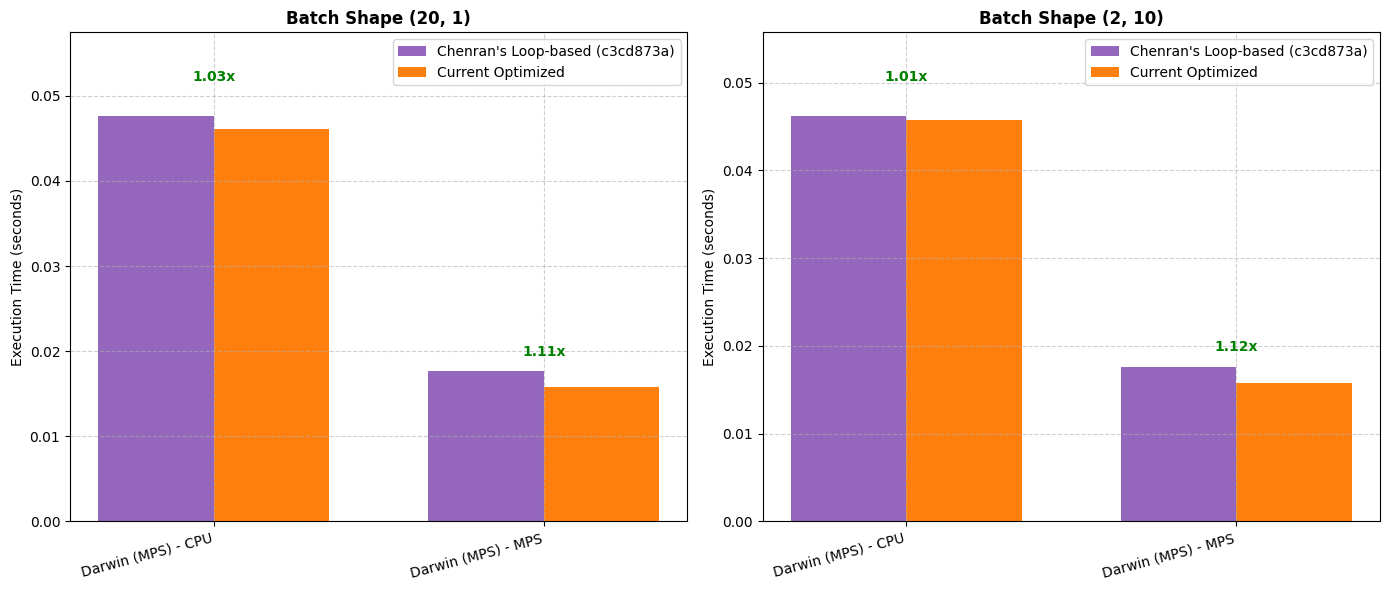

In [7]:
def plot_chenran_comparison(df):
    # Get configs
    configs = []
    for idx, row in df.iterrows():
        sys_name = row["System"]
        device = row["Device"]
        os_name = sys_name.split("|")[0].strip().split()[0]
        
        gpu_part = ""
        if "GPU:" in sys_name:
            gpu_name = sys_name.split("GPU:")[-1].strip()
            if "A100" in gpu_name:
                gpu_part = " (A100)"
            elif "MPS" in gpu_name:
                gpu_part = " (MPS)"
        
        label = f"{os_name}{gpu_part} - {device}"
        configs.append((sys_name, device, label))
        
    configs = list(set(configs))
    configs.sort(key=lambda x: x[2])
    
    batch_shapes = ["(20, 1)", "(2, 10)"]
    fig, axes = plt.subplots(1, len(batch_shapes), figsize=(14, 6), squeeze=False)
    
    for col_idx, shape in enumerate(batch_shapes):
        ax = axes[0, col_idx]
        sub_df = df[df["Batch Shape"] == shape]
        
        x_labels = []
        chenran_times = []
        opt_times = []
        speedups = []
        
        for _, (sys_name, dev, label) in enumerate(configs):
            config_df = sub_df[(sub_df["System"] == sys_name) & (sub_df["Device"] == dev)]
            if not config_df.empty:
                x_labels.append(label)
                chenran_times.append(config_df["Chenran's Loop-based (s)"].iloc[0])
                opt_times.append(config_df["Current Optimized (s)"].iloc[0])
                speedups.append(config_df["Speedup"].iloc[0])
                
        x = np.arange(len(x_labels))
        width = 0.35
        
        rects1 = ax.bar(x - width/2, chenran_times, width, label="Chenran's Loop-based (c3cd873a)", color="#9467bd")
        rects2 = ax.bar(x + width/2, opt_times, width, label="Current Optimized", color="#ff7f0e")
        
        ax.set_title(f"Batch Shape {shape}", fontsize=12, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=15, ha="right")
        ax.set_ylabel("Execution Time (seconds)")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.6)
        
        # Add speedup labels
        for i in range(len(x_labels)):
            val = speedups[i]
            max_val = max(chenran_times[i], opt_times[i])
            ax.text(i, max_val * 1.08, f"{val:.2f}x", ha="center", va="bottom", color="green", fontweight="bold")
            
        # Adjust y-limits
        _, y_max = ax.get_ylim()
        ax.set_ylim(top=y_max * 1.15)
        
    plt.tight_layout()
    plt.savefig("chenran_comparison.png", dpi=300)
    plt.show()

plot_chenran_comparison(combined_df)